# KoChatGPT 업그레이드 하기 [프로젝트]

LLM Trend Note 2023 [프로젝트] 노드의 KoChatGPT 코드(SFT → RM → PPO)를 기반으로 아래 세 가지를 진행합니다.

1. **기존 KoGPT2 vs SFT 모델** 결과를 정량/정성 비교
2. **SFT 모델 vs RM(PPO) 적용 모델** 결과를 정량/정성 비교
3. **데이터셋 정제 + 디코딩 하이퍼파라미터 서치 + 학습 전략 수정**으로 정량적 성능 향상

> 실행 환경: Colab **GPU 런타임**(T4 기준). 처음부터 끝까지 한 번에 실행하면 약 1시간 내외 걸립니다(추정). 시간이 부족하면 1장의 `TEST_N`, `VAL_N`, `RM_EVAL_N` 을 줄이세요.
> 중간에 런타임이 끊기면 `models/` 폴더가 사라지므로 처음부터 다시 실행해야 합니다.

## 0. 강의 코드 대비 변경점 요약

| 단계 | 모델 이름 | 강의 코드 대비 변경 | 왜 |
|---|---|---|---|
| Baseline | `base` | 없음 (KoGPT2 원본) | 비교 기준점 |
| Baseline | `sft_v1` | 평가용 질문(holdout)을 학습 데이터에서 제외 | 학습에 쓴 질문으로 평가하면 점수가 부풀려짐 |
| Baseline | `rm_v1` | holdout 제외 외에는 강의 그대로 | 강의 baseline 재현 |
| Baseline | `ppo_v1` | holdout 제외 외에는 강의 그대로 | 강의 baseline 재현 |
| 개선 ① | `sft_v2` | **데이터 정제**(따옴표·파싱 잔재·영어/한자 답변·중복 제거) + **프롬프트 증강**으로 크기 유지 + 2 epoch | 루브릭 3-1 (데이터 정제) |
| 개선 ② | `+best` | 6가지 **디코딩 설정**을 검증셋에서 비교해 최적값 선택 | 루브릭 3-1 (generation 기법 실험) |
| 개선 ③ | `rm_v2` | **ranking 해석 오류 수정** + 정제 + SFT와 같은 템플릿 형식 + 학습 쌍 1,000 → 3,000 | 루브릭 3-3 (학습 전략) |
| 개선 ④ | `ppo_v2` | actor=`sft_v2`, RM=`rm_v2`, PPO 프롬프트에 템플릿 적용, **left padding**, episode 10 → 20 | 루브릭 3-3 (학습 전략) |

**정량 평가 지표**

| 지표 | 의미 | 방향 |
|---|---|---|
| BLEU | 정답(ChatGPT 답변)과 n-gram(1~4)이 얼마나 겹치는가 (정밀도 중심) | 높을수록 좋음 |
| ROUGE-1/2/L | 정답과 unigram / bigram / 최장 공통 부분열이 얼마나 겹치는가 (F1) | 높을수록 좋음 |
| distinct-2 | 전체 답변에서 서로 다른 bigram 비율 (표현 다양성) | 높을수록 좋음 |
| repeat | 한 답변 안에서 반복되는 3-gram 비율 (같은 말 되풀이) | 낮을수록 좋음 |
| RM score | 학습한 Reward Model이 매긴 답변 점수 | 높을수록 좋음 |
| RM 정확도 | RM이 (좋은 답변, 나쁜 답변) 쌍에서 좋은 쪽에 더 높은 점수를 준 비율 | 높을수록 좋음 |

코드에서 강의 코드를 고친 줄은 `# [변경]`, 새로 추가한 코드는 `# [추가]` 주석으로 표시했습니다.

## 1. 환경 준비

In [1]:
# 그래프에 한글이 깨지지 않도록 나눔 폰트 설치 (지난 프로젝트와 동일)
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

print("슝=3")

슝=3


아래 코드 셀 세 개는 강의와 동일한 준비 작업입니다. (패키지 설치 → 버전 확인 → 참조 저장소 clone)

- `loralib` : chatgpt 패키지의 LoRA 구현이 사용합니다.
- `transformers==4.48.3` : 참조 코드(2023년 ColossalAI Chat 스냅숏)가 검증된 버전입니다. 최신 v5 에서는 kogpt2 토크나이저가 다르게 동작해 문장이 깨지므로 4.x 를 씁니다.
- `nltk` : [추가] BLEU 계산에 사용합니다.

설치 뒤 `huggingface_hub` 버전 충돌 경고가 나올 수 있는데, 이 노드에서 쓰지 않는 패키지에 관한 것이라 무시해도 됩니다.

In [2]:
# 참조 코드가 맞춰져 있는 transformers 버전으로 설치합니다. 이미 있는 버전과 다르면 바꿔 설치됩니다.
!pip install -q loralib==0.1.2 transformers==4.48.3
!pip install -q nltk   # [추가] BLEU 계산용

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 461.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
!pip show loralib transformers tokenizers | grep -E "^(Name|Version)"

Name: loralib
Version: 0.1.2
Name: transformers
Version: 4.48.3
Name: tokenizers
Version: 0.21.4


In [4]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 14.56 MiB/s, done.
Resolving deltas: 100% (123/123), done.
Updating files: 100% (105/105), done.


Colab 환경에는 참조 코드가 기대하는 `colossalai` 패키지가 없고(분산 학습용), 진행 표시줄도 노트북용으로 바꾸는 것이 보기 좋아 clone 한 소스 다섯 파일의 몇 줄을 고친 뒤 진행합니다. (강의 코드 그대로)

| 파일 | 바꾸는 내용 |
|---|---|
| `chatgpt/trainer/callbacks/save_checkpoint.py` | `ColossalAIStrategy` import 제거, 분기 조건을 항상 참으로 |
| `chatgpt/trainer/strategies/__init__.py` | `ColossalAIStrategy` import·`__all__` 제거 |
| `chatgpt/dataset/reward_dataset.py`, `chatgpt/trainer/base.py`, `chatgpt/trainer/rm.py` | `tqdm` → `tqdm.notebook` |

In [5]:
import os

# line 은 0 부터 세는 줄 번호. 그 줄이 old 와 같을 때만 new 로 바꾼다.
modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = True"},   # ColossalAI 를 쓰지 않으므로 항상 rank 0 에서 저장
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [{"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"}],
    },
    {
        "file": "chatgpt/trainer/base.py",
        "changes": [{"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"}],
    },
    {
        "file": "chatgpt/trainer/rm.py",
        "changes": [{"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"}],
    },
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            elif lines[line_index].strip() == change["new"].strip():
                print(f"ℹ️ {file_path} {line_index}번 줄은 이미 수정되어 있습니다.")
            else:
                print(f"⚠️ {file_path} 파일의 {line_index}번 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
✅ 수정 완료: chatgpt/trainer/base.py
✅ 수정 완료: chatgpt/trainer/rm.py


In [6]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__))
print("Cuda version: {}".format(torch.version.cuda))
print("transformers version: {}".format(transformers.__version__))  # 4.48.3 이어야 한다
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.11.0+cu128
Cuda version: 12.8
transformers version: 4.48.3
GPU 사용 가능여부: True


In [7]:
# [추가] 프로젝트 전체에서 공통으로 쓰는 라이브러리 / 설정
import json
import re
import gc
import copy
import random
import logging
import collections
import numpy as np
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def seed_everything(seed=42):
    """실행할 때마다 같은 결과가 나오도록 모든 난수 시드를 고정"""
    random.seed(seed)                 # 파이썬 random (데이터 셔플 등)
    np.random.seed(seed)              # numpy 난수
    torch.manual_seed(seed)           # torch CPU 난수 (가중치 초기화, 샘플링 등)
    torch.cuda.manual_seed_all(seed)  # torch GPU 난수
    transformers.set_seed(seed)       # transformers 내부 난수

def clear_memory():
    """다 쓴 모델을 del 한 뒤 호출해서 GPU 메모리를 비움 (Colab GPU 한 장으로 여러 모델을 차례로 학습하기 위함)"""
    gc.collect()               # 파이썬에서 더 이상 참조되지 않는 객체 정리
    torch.cuda.empty_cache()   # torch 가 잡아두고 있던 GPU 캐시 메모리 반환

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = 'skt/kogpt2-base-v2'        # foundation model (강의와 동일)
DATA_DIR = 'KoChatGPT/data_kochatgpt'    # 원본 데이터 폴더
WORK_DIR = 'data_project'                # 분할/정제한 데이터를 저장할 폴더
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)

# 평가셋 크기 (시간이 부족하면 줄여도 됩니다)
TEST_N = 100      # 최종 비교용 테스트 질문 수
VAL_N = 50        # 디코딩 하이퍼파라미터 서치용 검증 질문 수
RM_EVAL_N = 300   # RM 정확도 평가용 질문 수 (질문 1개당 비교 쌍 3개 → 900쌍)

print("슝=3")

슝=3


## 2. 공통 도구 (생성 함수 · 평가 지표)

여러 모델을 **같은 조건**에서 비교해야 하므로, 생성과 평가를 함수로 한 번만 정의해두고 모든 단계에서 재사용합니다.

- `generate_answers()` : 질문 리스트 → 강의의 프롬프트 템플릿을 씌워 배치로 생성 → 템플릿 부분을 뺀 **답변만** 반환
  - 여러 문장을 한 번에(배치로) 생성할 때는 **왼쪽 패딩(left padding)** 이 필요합니다. GPT는 문장의 맨 끝 토큰 다음을 이어서 생성하는데, 오른쪽에 `<pad>`가 붙어 있으면 패딩 뒤에서 생성을 시작하게 되기 때문입니다.
- `evaluate_answers()` : 생성 답변과 정답(ChatGPT 답변)을 비교해 BLEU / ROUGE / distinct-2 / repeat 계산
  - 한국어는 띄어쓰기 단위가 아니라 **KoGPT2 토크나이저의 subword 단위**로 n-gram을 셉니다. (조사가 붙은 어절 단위로 세면 거의 겹치지 않기 때문)
  - `rouge_score` 라이브러리는 기본 토크나이저가 영어 외 문자를 지워버려서, ROUGE는 직접 구현했습니다.
- `rm_scores()` : Reward Model로 (질문, 답변)에 점수 매기기 — `RewardDataset`과 같은 형식(질문+답변+`<|endoftext|>`, 512 패딩)으로 넣어야 학습 때와 조건이 같아집니다.

In [8]:
# [추가] 강의에서 SFT 추론에 쓰던 프롬프트 템플릿 (여러 단계에서 공통으로 쓰기 위해 위로 올림)
PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

def build_prompt(question):
    """질문 문자열에 SFT 학습 때와 같은 템플릿을 씌움"""
    return PROMPT_DICT['prompt_input'].format_map({'prompt': question})

# 생성용 토크나이저: 강의와 같은 특수토큰 설정 + 배치 생성을 위해 왼쪽 패딩
gen_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="left",          # 배치 생성 시 문장 끝이 가지런히 오른쪽에 오도록
    model_max_length=512,
)

# RM 점수용 토크나이저: RewardDataset 과 동일하게 오른쪽 패딩
rm_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

@torch.no_grad()   # 생성(추론)만 하므로 gradient 계산을 꺼서 메모리/속도 절약
def generate_answers(model, questions, gen_args, batch_size=16, seed=42):
    """질문 리스트를 받아 템플릿을 씌워 생성하고, 템플릿을 제외한 답변만 리스트로 반환"""
    seed_everything(seed)                     # 샘플링이 들어간 디코딩도 모델끼리 같은 조건으로 비교
    model.eval()                              # dropout 끄기
    answers = []
    for i in tqdm(range(0, len(questions), batch_size), desc='generate', leave=False):
        prompts = [build_prompt(q) for q in questions[i:i + batch_size]]
        enc = gen_tokenizer(prompts, return_tensors='pt', padding=True).to(model.device)
        enc.pop('token_type_ids', None)       # kogpt2 토크나이저가 주는 token_type_ids 는 GPT2 에서 불필요(넣으면 임베딩이 더해짐)
        kwargs = dict(pad_token_id=gen_tokenizer.pad_token_id,
                      eos_token_id=gen_tokenizer.eos_token_id)   # 답변 끝(</s>)이 나오면 생성 중단
        kwargs.update(gen_args)                                   # 디코딩 설정 (beam, top_k 등)
        out = model.generate(**enc, **kwargs)
        new_tokens = out[:, enc['input_ids'].shape[1]:]           # 입력(템플릿+질문) 뒤에 새로 생성된 부분만
        texts = gen_tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        answers.extend([t.strip() for t in texts])
    return answers

print("슝=3")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

슝=3


In [9]:
# [추가] 정량 평가 지표
smooth = SmoothingFunction().method1   # 짧은 문장에서 4-gram 이 하나도 안 겹쳐 BLEU 가 0 이 되는 것을 완화

def tok(s):
    """평가용 토큰화: KoGPT2 subword 단위"""
    return gen_tokenizer.tokenize(s)

def ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def rouge_n(pred, ref, n):
    """ROUGE-N F1: 예측과 정답의 n-gram 겹침"""
    p, r = collections.Counter(ngrams(pred, n)), collections.Counter(ngrams(ref, n))
    overlap = sum((p & r).values())                 # 겹치는 n-gram 개수 (중복 고려)
    if overlap == 0:
        return 0.0
    precision, recall = overlap / sum(p.values()), overlap / sum(r.values())
    return 2 * precision * recall / (precision + recall)

def lcs_len(a, b):
    """최장 공통 부분열(LCS) 길이 — 1차원 DP로 메모리 절약"""
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            cur = dp[j]
            dp[j] = prev + 1 if x == y else max(dp[j], dp[j - 1])
            prev = cur
    return dp[-1]

def rouge_l(pred, ref):
    """ROUGE-L F1: 순서를 지키며 겹치는 가장 긴 토큰열 기준"""
    l = lcs_len(pred, ref)
    if l == 0:
        return 0.0
    precision, recall = l / len(pred), l / len(ref)
    return 2 * precision * recall / (precision + recall)

def repeat_rate(tokens, n=3):
    """한 답변 안에서 중복된 3-gram 비율 (같은 말 되풀이 정도)"""
    g = ngrams(tokens, n)
    return 0.0 if not g else 1 - len(set(g)) / len(g)

def evaluate_answers(preds, refs):
    """생성 답변 리스트와 정답 리스트로 지표 계산 (0~100 스케일)"""
    P = [tok(p) for p in preds]
    R = [tok(r) for r in refs]
    bleu = [sentence_bleu([r], p, smoothing_function=smooth) if p else 0.0 for p, r in zip(P, R)]
    all_bigrams = [g for p in P for g in ngrams(p, 2)]
    return {
        'BLEU':       100 * np.mean(bleu),
        'ROUGE-1':    100 * np.mean([rouge_n(p, r, 1) for p, r in zip(P, R)]),
        'ROUGE-2':    100 * np.mean([rouge_n(p, r, 2) for p, r in zip(P, R)]),
        'ROUGE-L':    100 * np.mean([rouge_l(p, r) for p, r in zip(P, R)]),
        'distinct-2': 100 * (len(set(all_bigrams)) / max(1, len(all_bigrams))),
        'repeat':     100 * np.mean([repeat_rate(p) for p in P]),
        'avg_len':    np.mean([len(p) for p in P]),
    }

RESULTS = {}   # 모델별 테스트셋 생성 답변 {이름: [답변, ...]}
SCORES = {}    # 모델별 지표 {이름: {지표: 값}}

def run_eval(name, model, gen_args, questions=None, refs=None):
    """테스트셋으로 생성 → 지표 계산 → 결과 저장"""
    questions = test_q if questions is None else questions
    refs = test_ref if refs is None else refs
    RESULTS[name] = generate_answers(model, questions, gen_args)
    SCORES[name] = evaluate_answers(RESULTS[name], refs)
    return pd.DataFrame(SCORES).T.round(2)

def compare(a, b):
    """두 모델의 지표를 나란히 놓고 변화량 표시"""
    df = pd.DataFrame({a: SCORES[a], b: SCORES[b]})
    df['변화(b-a)'] = df[b] - df[a]
    return df.round(2)

def show_samples(names, idxs=(0, 1, 2), max_chars=250):
    """테스트 질문 몇 개에 대해 모델별 답변을 나란히 출력 (정성 평가용)"""
    for i in idxs:
        print('=' * 100)
        print('[질문]', test_q[i])
        print('[정답(ChatGPT)]', test_ref[i][:max_chars])
        for name in names:
            print(f'--- [{name}]', RESULTS[name][i][:max_chars])

@torch.no_grad()
def rm_scores(rm, prompts, answers, use_template, max_length=512, batch_size=8):
    """Reward Model 점수: RewardDataset 과 같은 형식(질문+답변+<|endoftext|>)으로 만들어 점수를 매김"""
    rm.eval()
    scores = []
    for i in range(0, len(prompts), batch_size):
        texts = []
        for p, a in zip(prompts[i:i + batch_size], answers[i:i + batch_size]):
            head = build_prompt(p) if use_template else p   # rm_v1 은 질문 그대로, rm_v2 는 템플릿 형식으로 학습
            texts.append(head + a + "<|endoftext|>")
        enc = rm_tokenizer(texts, max_length=max_length, padding="max_length",
                           truncation=True, return_tensors="pt").to(device)
        scores.extend(rm(enc['input_ids'], attention_mask=enc['attention_mask']).float().cpu().tolist())
    return scores

def rm_pairwise_accuracy(rm, pairs, use_template):
    """(chosen, rejected) 쌍에서 chosen 점수가 더 높은 비율 = RM 정확도"""
    c = np.array(rm_scores(rm, [p['prompt'] for p in pairs], [p['chosen'] for p in pairs], use_template))
    r = np.array(rm_scores(rm, [p['prompt'] for p in pairs], [p['rejected'] for p in pairs], use_template))
    return {'accuracy': 100 * float((c > r).mean()), 'mean_margin': float((c - r).mean())}

print("슝=3")

슝=3


## 3. 데이터셋 확인 · EDA · 평가셋 분리

### 3-1. 데이터셋 확인 (강의 코드)

In [10]:
import json
data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

In [11]:
data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

In [12]:
data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

In [13]:
# [추가] 세 데이터셋을 각각 다른 변수로 보관 (강의 코드는 list_data_dict 하나를 덮어쓰며 사용)
def load_json(path):
    with open(path, "r", encoding='utf-8-sig') as f:
        return json.load(f)

data_sft = load_json(data_path_1_SFT)
data_rm = load_json(data_path_2_RM)
data_ppo = load_json(data_path_3_PPO)

p_sft = set(x['prompt'] for x in data_sft)
p_rm = set(x['prompt'] for x in data_rm)
p_ppo = set(x['prompt'] for x in data_ppo)
print(f"SFT {len(data_sft):,} / RM {len(data_rm):,} / PPO {len(data_ppo):,}")
print(f"RM 질문 중 SFT에도 있는 것: {len(p_rm & p_sft):,} / {len(p_rm):,}")
print(f"PPO 질문 중 SFT에도 있는 것: {len(p_ppo & p_sft):,} / {len(p_ppo):,}")

SFT 12,000 / RM 10,220 / PPO 12,000
RM 질문 중 SFT에도 있는 것: 10,181 / 10,181
PPO 질문 중 SFT에도 있는 것: 11,946 / 11,946


세 데이터셋의 질문(prompt)이 거의 전부 겹칩니다. 즉 **평가용 질문은 세 데이터셋 모두에서 빼야** SFT·RM·PPO 어느 단계에서도 "본 적 없는 질문"으로 평가할 수 있습니다. (강의 코드는 전체 데이터로 학습하고 학습에 쓴 질문으로 결과를 확인합니다.)

### 3-2. SFT 데이터 EDA

답변(completion)을 직접 살펴보면 전처리가 덜 된 흔적이 눈에 띕니다.

In [14]:
# [추가] SFT 답변(completion) 품질 점검
comps = [x['completion'] for x in data_sft]

RESIDUE_TAIL = re.compile(r"""["']?\s*,\s*'token'\s*:\s*\d+\s*\}?\s*$""")   # 끝에 붙은 ", 'token': 154}" 파싱 잔재
RESIDUE_HEAD = re.compile(r"""^.*?'completion'\s*:\s*["']""", re.S)           # 앞에 붙은 "'completion': " 파싱 잔재

def hangul_ratio(s):
    """글자(한글+영문) 중 한글 비율"""
    letters = re.findall(r'[가-힣A-Za-z]', s)
    return 0 if not letters else len(re.findall(r'[가-힣]', s)) / len(letters)

eda = {
    "맨 앞 따옴표(' 또는 \")로 시작": sum(s.startswith(("'", '"')) for s in comps),
    "끝에 \", 'token': N} 파싱 잔재": sum(bool(RESIDUE_TAIL.search(s)) for s in comps),
    "줄바꿈이 문자 그대로 '\\n'으로 저장": sum('\\n' in s for s in comps),
    "영어 위주 답변(한글 비율<50%)": sum(hangul_ratio(s) < 0.5 for s in comps),
    "한자 포함 답변": sum(bool(re.search(r'[一-鿿]', s)) for s in comps),
    "빈 질문": sum(len(x['prompt'].strip()) == 0 for x in data_sft),
    "중복 질문": len(data_sft) - len(set(x['prompt'] for x in data_sft)),
    "AI 자기소개 문구('저는 인공지능…')": sum(bool(re.search(r'(저는|나는) (인공지능|AI)', s)) for s in comps),
}
display(pd.DataFrame.from_dict(eda, orient='index', columns=['개수']))

print("\n[예시] 파싱 잔재:", [s[-45:] for s in comps if RESIDUE_TAIL.search(s)][:2])
print("[예시] 영어 답변:", [(x['prompt'], x['completion']) for x in data_sft if hangul_ratio(x['completion']) < 0.5][:3])

,개수
"맨 앞 따옴표(' 또는 "")로 시작",11975
"끝에 "", 'token': N} 파싱 잔재",505
줄바꿈이 문자 그대로 '\n'으로 저장,1238
영어 위주 답변(한글 비율<50%),585
한자 포함 답변,154
빈 질문,3
중복 질문,54
AI 자기소개 문구('저는 인공지능…'),1892



[예시] 파싱 잔재: [' 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", \'token\': 154}', '더쉽 평가에서 1위로 선정된 신문은 \'조선일보\'입니다.", \'token\': 85}']
[예시] 영어 답변: [('미스터 허드슨 & 더 라이브러리가 서포팅 밴드로 참여했으며, 아일랜드 더블린 및 유럽 도시들에서 열린 카니예 웨스트의 공연 명은?', '\'"Canyon Tour" 입니다.'), ('목 마르다.', '\'> "I am thirsty." (English) \\n\\n> "Je suis assoiffé." (French) \\n\\n> "Tengo sed." (Spanish) \\n\\n> "Ich bin durstig." (German) \\n\\n> "나는 목이 마르다." (Korean)'), ('동거 8년 환승이별.', "'8 years of living together, transfer separation.")]


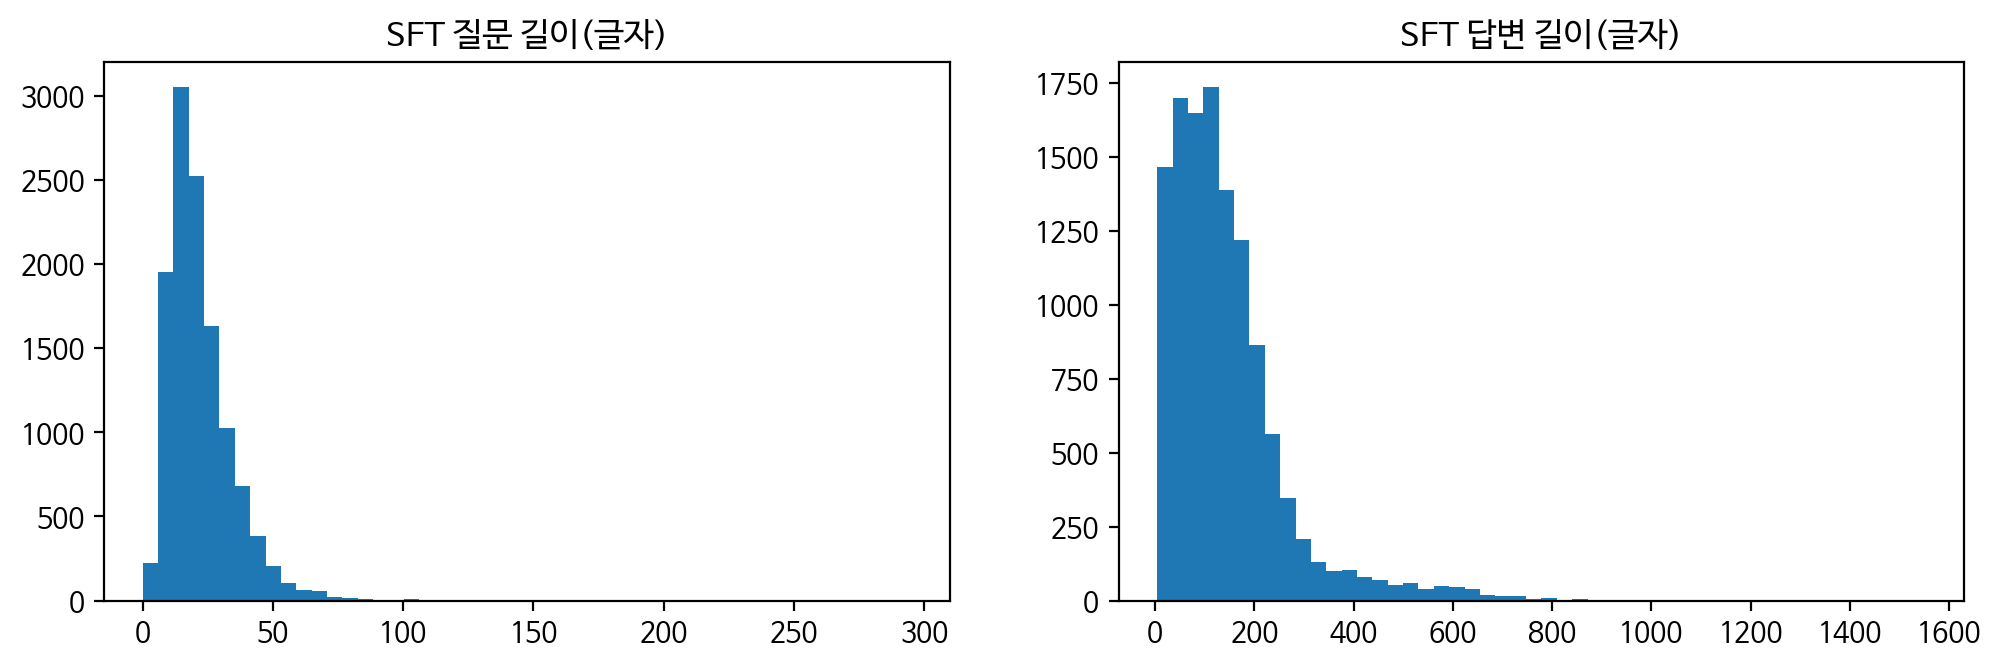

count    12000.0
mean       144.1
std        122.8
min          4.0
25%         62.0
50%        118.0
75%        185.0
max       1553.0
dtype: float64


In [15]:
# [추가] 길이 분포 (글자 수)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist([len(x['prompt']) for x in data_sft], bins=50)
axes[0].set_title('SFT 질문 길이(글자)')
axes[1].hist([len(x['completion']) for x in data_sft], bins=50)
axes[1].set_title('SFT 답변 길이(글자)')
plt.show()

print(pd.Series([len(x['completion']) for x in data_sft]).describe().round(1))

**EDA 결과 정리**

- 답변 대부분이 `'`로 시작합니다. 데이터 생성 시 문자열 따옴표가 같이 저장된 것으로, 모델이 "답변은 `'`로 시작한다"를 학습하게 됩니다.
- 일부 답변 끝에 `", 'token': 154}` 같은 **파싱 잔재**가 붙어 있고, 줄바꿈이 실제 줄바꿈이 아니라 `\n` 두 글자로 저장되어 있습니다.
- 한국어 질문에 **영어로 답한** 샘플(번역체 답변 등)과 **한자**가 섞인 답변이 있습니다. 강의 마무리에서 언급된 "맥락에서 벗어난 한문이나 영문 출력"의 원인 중 하나로 볼 수 있습니다.
- 빈 질문, 중복 질문도 소수 있습니다.
- 'AI 자기소개 문구'는 ChatGPT 특유의 말투이지만 틀린 답변은 아니므로 **제거하지 않고** 유지합니다.

### 3-3. RM 데이터의 `ranking` 해석 검증

강의 코드는 `ranking[i]`를 **"completion_i 의 순위"** (0이 최상)로 해석합니다.
그런데 저장소 README에 따르면 RM 데이터는 "ChatGPT > davinci > ada" 순서로 순위를 매겼고, SFT 데이터의 답변이 바로 그 ChatGPT 답변입니다.
그렇다면 **SFT 답변과 같은 completion이 항상 1등**이어야 하므로, 이것으로 두 해석 중 무엇이 맞는지 검증할 수 있습니다.

- 해석 A (강의): `ranking[i]` = completion_i 의 순위 → ChatGPT 답변 j 에 대해 `ranking[j] == 0` 이어야 함
- 해석 B: `ranking` = [1등 completion 번호, 2등 번호, 3등 번호] → `ranking[0] == j` 이어야 함

In [16]:
# [추가] ranking 해석 검증
def norm(s):
    """비교용 정규화: 앞뒤 공백/따옴표 제거"""
    return s.strip().strip('\'"').strip()

sft_answer = {x['prompt']: norm(x['completion']) for x in data_sft}

found = hit_a = hit_b = 0
for tmp in data_rm:
    comps3 = [norm(tmp[f'completion_{i}']) for i in range(3)]
    ans = sft_answer.get(tmp['prompt'])
    if ans in comps3:                              # RM의 세 답변 중 ChatGPT(=SFT) 답변 찾기
        found += 1
        j = comps3.index(ans)                      # ChatGPT 답변의 위치
        hit_a += (tmp['ranking'][j] == 0)          # 해석 A 로 보면 1등인가?
        hit_b += (tmp['ranking'][0] == j)          # 해석 B 로 보면 1등인가?

print(f"ChatGPT 답변을 찾은 샘플: {found:,}")
print(f"해석 A(강의)로 ChatGPT 답변이 1등인 비율: {hit_a / found:.1%}")
print(f"해석 B로 ChatGPT 답변이 1등인 비율   : {hit_b / found:.1%}")

# 강의 해석으로 만든 쌍 중 실제(해석 B)와 반대로 라벨링되는 비율
def true_rank(ranking):
    """해석 B 기준: completion 번호 -> 실제 순위"""
    return {idx: r for r, idx in enumerate(ranking)}

wrong = total = 0
for tmp in data_rm:
    rk = true_rank(tmp['ranking'])
    for a, b in [(0, 1), (0, 2), (1, 2)]:
        lecture_a_better = tmp['ranking'][a] < tmp['ranking'][b]   # 강의 해석
        true_a_better = rk[a] < rk[b]                               # 해석 B
        wrong += (lecture_a_better != true_a_better)
        total += 1
print(f"강의 해석으로 만든 {total:,}쌍 중 chosen/rejected 가 뒤바뀐 쌍: {wrong:,} ({wrong / total:.1%})")

# 해석이 갈리는 예시 (ranking 이 [1,2,0] 또는 [2,0,1] 인 경우)
ex = next(t for t in data_rm if tuple(t['ranking']) in [(1, 2, 0), (2, 0, 1)])
print('\n[예시] ranking =', ex['ranking'])
for i in range(3):
    print(f"  completion_{i}: {ex[f'completion_{i}'][:80]}")

ChatGPT 답변을 찾은 샘플: 10,176
해석 A(강의)로 ChatGPT 답변이 1등인 비율: 66.2%
해석 B로 ChatGPT 답변이 1등인 비율   : 100.0%
강의 해석으로 만든 30,660쌍 중 chosen/rejected 가 뒤바뀐 쌍: 6,900 (22.5%)

[예시] ranking = [2, 0, 1]
  completion_0: 개포주공아파트는 다섯 단지로 이루어져 있습니다.
  completion_1: 이날 목송에서 구글상위노
  completion_2: 개포주공아파트는 총 27개 단지로 이루어져 있습니다.


해석 B에서 ChatGPT 답변이 거의 100% 1등으로 나오므로, **`ranking`은 "1등부터 순서대로 나열한 completion 번호"** 입니다.
`[0,1,2]`, `[0,2,1]`, `[1,0,2]`, `[2,1,0]` 처럼 두 해석이 우연히 같은 결과를 내는 경우도 있지만, `[1,2,0]`, `[2,0,1]` 인 샘플(약 1/3)은 강의 해석으로 쌍을 만들면 좋은 답과 나쁜 답이 뒤바뀝니다.
→ 강의 baseline(`rm_v1`)은 그대로 재현하고, 개선 단계(`rm_v2`)에서 이 해석을 바로잡습니다.

### 3-4. 정제 함수 정의 · 평가셋(holdout) 분리

평가 정답은 깨끗해야 하므로, 먼저 정제 함수를 정의하고 **정제를 통과한 SFT 샘플 중에서** 평가 질문을 뽑습니다.

In [17]:
# [추가] SFT 답변 정제 함수 & 필터
def clean_text(s):
    """답변 문자열 정제: 파싱 잔재 제거, 줄바꿈 복원, 앞 따옴표 제거"""
    s = s.strip()
    s = RESIDUE_TAIL.sub('', s)                                          # 끝의 ", 'token': N} 제거
    s = RESIDUE_HEAD.sub('', s)                                          # 앞의 'completion': 제거
    s = s.replace('\\n', '\n').replace("\\'", "'").replace('\\"', '"')   # 문자 그대로 저장된 \n, \' 복원
    s = re.sub(r"^['\"]+", '', s).strip()                                # 맨 앞 따옴표 제거
    for q in ['"', "'"]:
        if s.endswith(q) and s.count(q) % 2 == 1:                        # 짝이 안 맞는 끝 따옴표 제거
            s = s[:-1].rstrip()
    return s

def filter_reason(prompt, completion):
    """제거 사유를 반환 (통과하면 None)"""
    if not prompt:
        return '빈 질문'
    if hangul_ratio(completion) < 0.5:
        return '영어 위주 답변'
    if re.search(r'[一-鿿]', completion):
        return '한자 포함'
    if len(completion) < 2 or len(completion) > 1000:
        return '너무 짧거나 긴 답변'
    sents = [t.strip() for t in re.split(r'(?<=[.!?])\s+', completion) if t.strip()]
    if sents and max(collections.Counter(sents).values()) >= 3:
        return '같은 문장 3회 이상 반복'
    return None

sft_clean, drop_reasons, seen = [], collections.Counter(), set()
for x in data_sft:
    p, c = x['prompt'].strip(), clean_text(x['completion'])
    if p in seen:                                  # 중복 질문은 처음 것만 사용
        drop_reasons['중복 질문'] += 1
        continue
    reason = filter_reason(p, c)
    if reason:
        drop_reasons[reason] += 1
        continue
    seen.add(p)
    sft_clean.append({'prompt': p, 'completion': c})

print(f"정제 전 {len(data_sft):,} → 정제 후 {len(sft_clean):,}")
display(pd.DataFrame.from_dict(drop_reasons, orient='index', columns=['제거 개수']))

print('\n[정제 전]', repr(data_sft[0]['completion'][:60]))
print('[정제 후]', repr(clean_text(data_sft[0]['completion'])[:60]))

정제 전 12,000 → 정제 후 11,215


,제거 개수
영어 위주 답변,574
한자 포함,152
중복 질문,48
빈 질문,3
같은 문장 3회 이상 반복,2
너무 짧거나 긴 답변,6



[정제 전] "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 "
[정제 후] '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고'


In [18]:
# [추가] 평가용 질문(holdout) 분리 — 세 데이터셋 모두에서 제외
random.seed(42)
clean_map = {x['prompt']: x['completion'] for x in sft_clean}
rm_map = {x['prompt']: x for x in data_rm}

candidates = sorted(set(clean_map) & set(rm_map))   # 정제 통과 + RM 데이터에도 있는 질문
random.shuffle(candidates)
test_prompts = candidates[:TEST_N]
val_prompts = candidates[TEST_N:TEST_N + VAL_N]
rm_eval_prompts = candidates[TEST_N + VAL_N:TEST_N + VAL_N + RM_EVAL_N]
HOLDOUT = set(test_prompts) | set(val_prompts) | set(rm_eval_prompts)

# 테스트/검증셋: 질문 + 정제된 정답(ChatGPT 답변)
test_q, test_ref = test_prompts, [clean_map[p] for p in test_prompts]
val_q, val_ref = val_prompts, [clean_map[p] for p in val_prompts]

# RM 정확도 평가 쌍: 올바른 해석(해석 B) + 정제된 텍스트
rm_eval_pairs = []
for p in rm_eval_prompts:
    tmp = rm_map[p]
    order = tmp['ranking']                           # [1등 번호, 2등 번호, 3등 번호]
    for a, b in [(0, 1), (0, 2), (1, 2)]:            # 순위 a 가 순위 b 보다 좋음
        rm_eval_pairs.append({'prompt': p,
                              'chosen': clean_text(tmp[f'completion_{order[a]}']),
                              'rejected': clean_text(tmp[f'completion_{order[b]}'])})

# 학습용 데이터 (holdout 제외)
sft_v1_train = [x for x in data_sft if x['prompt'] not in HOLDOUT]      # 원본 그대로 (baseline)
rm_train_raw = [x for x in data_rm if x['prompt'] not in HOLDOUT]
ppo_train_prompts = [x['prompt'] for x in data_ppo if x['prompt'] not in HOLDOUT]

# SFT_dataset 클래스가 파일 경로를 받으므로 파일로 저장
SFT_V1_PATH = f'{WORK_DIR}/kochatgpt_1_SFT_v1_train.jsonl'
with open(SFT_V1_PATH, 'w', encoding='utf-8') as f:
    json.dump(sft_v1_train, f, ensure_ascii=False)

print(f"test {len(test_q)} / val {len(val_q)} / rm_eval 쌍 {len(rm_eval_pairs)}")
print(f"SFT 학습 {len(sft_v1_train):,} / RM 학습 원본 {len(rm_train_raw):,} / PPO 프롬프트 {len(ppo_train_prompts):,}")
print('\n[테스트 예시]', test_q[0], '->', test_ref[0][:100])

test 100 / val 50 / rm_eval 쌍 900
SFT 학습 11,549 / RM 학습 원본 9,769 / PPO 프롬프트 11,549

[테스트 예시] 이별 일년 반 -> 이별 일년 반이란 말은, 이별한 후 일년 혹은 그 이상 동안 많은 변화가 있을 수 있다는 것을 의미합니다. 이는 마음이 아프고 슬픈 시간 동안에도, 시간이 흐르면서 마음이 치유되고


## 4. Baseline ① : KoGPT2 원본 (`base`)

### 4-1. 강의 코드 — 디코딩 방식별 생성 확인

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

In [20]:
print(tokenizer.model_max_length)   # 10³⁰ 같은 큰 수면 토크나이저 설정에 최대 길이가 없다는 뜻
print(model.config.n_positions)     # 실제로 모델이 처리할 수 있는 최대 토큰 수

1000000000000000019884624838656
1024


In [21]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


In [22]:
# 그리디 서치: 매 스텝 확률이 가장 높은 토큰 하나만 선택 → 같은 문장이 반복되기 쉬움
max_length=128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


In [23]:
# 빔 서치 + n-gram 패널티: 후보 10개를 유지하며 탐색, 같은 2-gram 반복 금지
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


In [24]:
# 샘플링 추가: temperature 가 클수록 확률 분포가 평평해져 다양(무작위)해지고, top_k 는 상위 k개 토큰 중에서만 샘플링
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까. 한낮의 태양 아래 노을이 드리워지고 있군요."
"그런데 뭔데요! 그거 뭐?"
그제야 문득 그 여자의 말이 생각났다!
그녀의 목소리에 입술을 씰룩거렸다.
"왜 그래요, 이거."
"정말 모르겠어요, 고마워요. 정말 미안해요. 저는 여기까지 왔으니까요. 그런데 아까 그 얘기는 왜 하셨어요? 왜 그렇게 생각하시는 겁니까? 그건 우리


In [25]:
# top_p: 누적 확률이 p(0.9)가 될 때까지의 토큰들 중에서만 샘플링 (후보 수가 상황에 따라 달라짐)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그런데 그 오동잎에 대해선 어떻게 생각하십니까?"
그녀는 잠시 생각에 잠겼다.
"아니, 그게 무슨 말씀이신지 모르겠어요."
그러자 그녀는 고개를 끄덕였다.
"무슨 말씀을 하시는 거예요? 저는 이 오동나무에 대해 알고 싶지 않습니다."
이렇게 말하면서 그녀는 한숨을 내쉬었다.
"이 오동나무도 저 오동나무가 아니에요. 그건 제가 알고 있는 오동나무의 한 종류일 뿐이죠."
"


### 4-2. [추가] 테스트셋 정량 평가

모든 모델을 같은 디코딩 설정으로 비교하기 위해 **강의의 SFT generator 설정(`generation_args`)을 기준 설정(`BASE_GEN_ARGS`)** 으로 사용합니다. 다만 두 가지를 바꿨습니다.

- `eos_token_id` : 강의는 `375`(`\n`)에서 멈추지만, SFT 학습 데이터의 답변 끝은 `</s>`이므로 `</s>`에서 멈추도록 변경 (정제 후 데이터에는 답변 중간에 줄바꿈이 있어서 `\n`에서 멈추면 답변이 잘립니다)
- `max_new_tokens` : 64 → 128 (정답 답변의 절반 정도가 64 토큰을 넘어서, 64로 자르면 모든 모델의 ROUGE가 일괄적으로 낮아짐)

In [26]:
# [추가] 비교 기준 디코딩 설정 (강의 generation_args 기반)
BASE_GEN_ARGS = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    max_new_tokens=128,        # [변경] 64 -> 128
    do_sample=True,
    top_k=50,
    early_stopping=True,
    # [변경] eos_token_id=375(\n) 삭제 -> generate_answers 안에서 </s> 로 지정
)

run_eval('base', model, BASE_GEN_ARGS)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len
base,0.08,0.99,0.09,0.89,21.44,6.65,125.79


In [27]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del model
clear_memory()

## 5. Baseline ② : Supervised Fine-Tuning (`sft_v1`)

강의 코드를 그대로 사용하되, 학습 데이터 경로만 holdout을 제외한 파일로 바꿨습니다.

In [28]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [29]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

GPT2TokenizerFast(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=

In [30]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100   # 질문(source) 부분은 loss 계산에서 제외 (CrossEntropyLoss 의 ignore_index=-100)

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [31]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)  # 패딩 위치도 loss 제외
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [32]:
train_dataset = SFT_dataset(data_path_1_SFT=SFT_V1_PATH, tokenizer=tokenizer)   # [변경] holdout 제외한 파일
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

In [33]:
# 강의 과제: train_dataset.input_ids[0] 와 labels[0] 디코딩
print('[input 디코딩]')
print(tokenizer.decode(train_dataset.input_ids[0]))
print('\n[labels 디코딩] (-100 은 토큰이 아니므로 빼고 디코딩)')
print(tokenizer.decode([t for t in train_dataset.labels[0].tolist() if t != -100]))

[input 디코딩]
### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>

[labels 디코딩] (-100 은 토큰이 아니므로 빼고 디코딩)
'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>


In [34]:
training_args = transformers.TrainingArguments(
    output_dir="test",
    overwrite_output_dir=True,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True,
    report_to="none",
    save_strategy="no",     # [변경] 중간 체크포인트 저장 안 함 (Colab 디스크/시간 절약, 마지막에 직접 저장)
    logging_steps=100,      # [변경] 100 스텝마다 loss 출력
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

In [35]:
trainer.train()
model.save_pretrained('models/output_1_SFT')

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,3.206200
200,3.040600
300,2.910500
400,2.876400
500,2.824300
600,2.782100
700,2.814900
800,2.775100
900,2.727300
1000,2.745800


In [36]:
# 강의 코드: pipeline 으로 빠르게 정성 확인
generator = transformers.pipeline('text-generation', model='models/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Device set to use cuda:0



### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 소고기, 돼지고기 등 다양한 부위를 사용합니다. 따라서 고기를 먹을 수 있는 식당이나 음식점에 문의하시는 것이 좋을 것 같습니다. "불고기용 고기의 종류

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 41대 부통령직을 수행했습니다. J. D.R. S. 케네디(James D. M. Kenneth) J.D.R. S. 케네디(Richard F. Kenneth)가 46대 부통령직을 맡았던 년도는 1961년입니다. J. D. R. S. 케네디(Joseph D. Kenneth)는

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'저는 인공지능 어시스턴트이므로 시카고에 대한 정보를 알 수 없습니다. 하지만 시카고 오헤어 공항은 미국 동부 지역에서 가장 유명한 국제공항 중 하나입니다. "시카고" 또는 "오사카" 라고 불립니다. "시카고시" 또는 "시카고"라고 불립니다. 이 외에도 많은

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'저는 인공지능 언어모델로써 정확한 답변을 제공하기 위해 노력하고 있습니다. 하지만 "미세먼지"가 어떤 문제인지 자세히 알려주시면 더 정확한 답변을 드릴 수 있을 것 같습니다. translation, please provide model, and context or


In [37]:
# [추가] 테스트셋 정량 평가
run_eval('sft_v1', model, BASE_GEN_ARGS)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len
base,0.08,0.99,0.09,0.89,21.44,6.65,125.79
sft_v1,5.05,17.90,8.56,15.11,50.45,1.26,50.28


### 5-1. [루브릭 1] 기존 KoGPT2 vs SFT 모델 비교

In [38]:
# [추가] 정량 비교
compare('base', 'sft_v1')

,base,sft_v1,변화(b-a)
BLEU,0.08,5.05,4.97
ROUGE-1,0.99,17.90,16.91
ROUGE-2,0.09,8.56,8.47
ROUGE-L,0.89,15.11,14.22
distinct-2,21.44,50.45,29.01
repeat,6.65,1.26,-5.38
avg_len,125.79,50.28,-75.51


In [39]:
# [추가] 정성 비교 (같은 질문에 대한 답변을 나란히)
show_samples(['base', 'sft_v1'], idxs=range(5))

[질문] 이별 일년 반
[정답(ChatGPT)] 이별 일년 반이란 말은, 이별한 후 일년 혹은 그 이상 동안 많은 변화가 있을 수 있다는 것을 의미합니다. 이는 마음이 아프고 슬픈 시간 동안에도, 시간이 흐르면서 마음이 치유되고 새로운 시작을 해 나갈 수 있음을 나타냅니다. 따라서 이별 일년 반이라는 말은, 이별을 겪은 사람들에게 더 나은 미래를 기대할 수 있다는 긍정적인 메세지를 전달합니다.
--- [base] ##스타그램 #셀카 #셀피 #selfie #daily #instagood #like4like #ootd #소통 #좋아요
#맞팔 #선팔 #일상 #데일리 #오오티디 #cafe #coffee #f4f #l4l #lfl #followme #outfit #menswear #20190706 #미
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 분들이라면 그 아픔을 느끼실 수 있을 것입니다. 함께 새로운 시작을 해보는 것은 어떨까요?
[질문] 좋아하는 사람이 생기면 좋을 줄 알았는데 우울하기만 해.
[정답(ChatGPT)] 그 사람이 아마 이미 다른 사람과 함께할 만큼 충분히 행복한 것 같습니다. 그래서 당신은 외로움과 좌절감을 느낄 수 있습니다. 그러나 이러한 감정을 천천히 받아들이고 자신의 삶에 만족할 수 있는 새로운 관심과 취미를 찾을 수도 있습니다. 좋아하는 사람이 생길 때까지 기다리는 것은 언제나 어렵겠지만, 인생은 예측 불허의 선물이며 당신도 언제든 새로운 만남과 기회를 만날 수 있습니다. 따라서 긍정적인 마인드로 앞으로 나아가는 것이 중요합니다.
--- [base] #ready #daily #like4like #selfie #instagood #ootd #outfitness #셀카 #셀피 #얼스타그램 #맞팔 #소통 #선팔 #일상 #데일리 #먹방 #먹부림 #먹짤 #위꼴 #인스타푸드 #좋아요
#팔로우미 #fff #f4f #l4l #follow
--- [sft_v1] '저는 AI 

**분석** (※ 실행 결과 수치를 보고 확인·수정)

- **정량**: SFT 후 BLEU·ROUGE가 모두 상승했는지 확인합니다. 원본 KoGPT2는 "질문에 답한다"는 것을 배운 적이 없어 템플릿 뒤에 아무 글이나 이어 쓰므로 정답과의 겹침이 매우 낮습니다.
- **정성**: 원본 KoGPT2는 질문과 무관한 뉴스·소설체 문장을 이어가거나 `### Instruction` 같은 템플릿 문구를 따라 만드는 경우가 많고, SFT 모델은 "~입니다/~하세요" 같은 **ChatGPT식 답변 형식**을 따르게 됩니다.
- 다만 SFT 모델도 사실관계(인물·연도 등)는 자주 틀립니다. SFT는 **답변의 형식과 말투**를 가르칠 뿐, 125M 규모 모델의 지식 한계는 그대로이기 때문입니다.

In [40]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del model, trainer, generator
clear_memory()

## 6. Baseline ③ : Reward Model (`rm_v1`)

강의 코드를 그대로 재현합니다. (ranking 해석도 강의 방식 그대로)

In [41]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

In [42]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)   # 마지막 hidden(768차원) -> 점수 1개(스칼라)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [43]:
# 강의 코드: AutoModelForCausalLM 을 먼저 불러오지만 바로 아래에서 GPTRM_custom 으로 덮어씀
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

In [44]:
list_data_dict = rm_train_raw   # [변경] 파일 전체 대신 holdout 을 제외한 RM 데이터

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    data = {}
    data['prompt'] = tmp['prompt']
    # 데이터의 ranking 은 [completion_0 의 순위, completion_1 의 순위, completion_2 의 순위] 이고 0 이 가장 좋은 답변이다.
    # 예: ranking = [2, 0, 1] 이면 completion_1 이 1등, completion_2 가 2등, completion_0 이 3등.
    # 아래에서는 두 답변씩 순위를 비교해 숫자가 작은(더 좋은) 쪽을 chosen, 큰 쪽을 rejected 로 둔다.
    # ※ [추가 메모] 3-3 검증 결과 이 해석은 약 1/3 샘플에서 틀림 → rm_v2 에서 수정
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 9769
after  data num: 29307
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


In [45]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '호르헤 카마초는 몇년도에 태어났어', 'chosen': '리서치 결과에 따르면, 호르헤 카마초는 1914년 6월 23일에 태어났습니다.', 'rejected': '요?\n\n호르헤 카마초는 1887년에 태어났습니다.'}


In [46]:
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [47]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
고기 따로 곰국 따로 팔아요?
######################################################################
## chosen ##
죄송합니다. 곰국과 고기는 함께 팔고 있습니다.
######################################################################
## rejected ##
No, it is not a word.


In [48]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=1)

In [49]:
trainer.fit(use_lora=0)

model.save_pretrained('models/output_2_RM')                                   # GPT2 백본만 저장된다
torch.save(model.value_head.state_dict(), 'models/output_2_RM/value_head.pt')  # 학습한 value head 도 따로 저장

Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/250 [00:00<?, ?it/s]

In [50]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: -3.3


In [51]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -3.5


In [52]:
input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -3.5


In [53]:
input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: -3.4


In [54]:
# [추가] RM 정량 평가: 올바른 라벨(해석 B)로 만든 holdout 쌍에서의 정확도
RM_SCORES = {}
RM_SCORES['rm_v1'] = rm_pairwise_accuracy(model, rm_eval_pairs, use_template=False)
pd.DataFrame(RM_SCORES).T.round(3)

,accuracy,mean_margin
rm_v1,90.111,0.17


In [55]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del model, trainer, train_dataset, eval_dataset
clear_memory()

## 7. Baseline ④ : PPO (`ppo_v1`)

강의 코드를 그대로 재현합니다. actor = SFT 모델, critic = RM 모델, initial model = SFT 모델 복사본(freeze), reward model = RM 복사본.

In [56]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

In [57]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='models/output_2_RM', lora_rank=0).to(torch.cuda.current_device())
    # GPTCritic 은 백본만 불러오고 value head 는 새로 만든다. RM 학습에서 얻은 head 를 덮어쓴다.
    critic.value_head.load_state_dict(torch.load('models/output_2_RM/value_head.pt'))
    tokenizer = AutoTokenizer.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

In [58]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [59]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

In [60]:
list_prompt = ppo_train_prompts   # [변경] 파일 전체 대신 holdout 을 제외한 PPO 프롬프트

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [61]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))
len(list_prompt)

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


11549

In [62]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

In [63]:
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO')

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [9/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

In [64]:
def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'네, 불고기와 돼지고기는 따로 판매되는 메뉴가 아닌 것으로 알려져 있습니다. 따라서 질문이 너무 부족해 죄송합니다. Korean을 참고해 주시기 바랍니다. Korean 에는 돼지고기가 들어간 음식도 없고, 국내에서는 고기와 함께 먹을 수 있는 다양한 음식이 있으므로 국내 상황에 맞게 선택하실 수 있을 것입니다. Hed의 Hed가 Hed의 Hed에 비해 더 많이 수입되는 것은 알고 있습니다. Korean을 참고해 주시면 더 자세한 정보를 제공해 드릴 수 있습니다. Korean을 참고하시면 더 정확한 답변을 드릴 수 있습니다. Loref는 현재까지도 가장 많이 판매되는 음식 중 하나로 알려져 있습니다. Eore는 AI 언어 모델로 제작된 언어 모델로, 실제 사용되는 모델보다 더 많은 언어 모델을 사용하지만, 어떤 맥락을 사용하느냐에 따라 더 많은 답변을 드릴 수 있을 것입니다. Hed의 Hed와 Hed는 완전히 무관합니다. Hed는 동일한 방식으로 제조되었습니다. Hed는 현재까지도 널리 사용되는 음식 중 하나이기 때문에, 정확한 정보가 필요합니다. Hed가

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):"리처드 닉슨은 2004년이다. "Friedrich Ninema"로 검색해 보면 이 년도는 더 많은 정보가 제공될 가능성이 있다. 그러나 닉슨은 후보자로도 출마하지 않았으므로, 후보자 출마가능성에 대해서는 아직 확실하지 않다.", 'token': 122} "리처드 닉슨은 41대 부통령직에서 수행한 대통령이다.", 'token': 120} "리처드 닉슨은 44대 부통령직을 수행한 대통령"은 현재 어디에도 존재하지 않습니다. "리처드 닉슨은 43대 부통령직에서 수행한 대통령", 'token': 105} "리처드 닉슨은 43대 부통령직'에서 수행한 대통령" (Posting "리처드 닉슨은 39대 

In [65]:
# [추가] 테스트셋 정량 평가 (actor.model 이 실제 GPT2 언어모델)
run_eval('ppo_v1', actor.model, BASE_GEN_ARGS)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len
base,0.08,0.99,0.09,0.89,21.44,6.65,125.79
sft_v1,5.05,17.90,8.56,15.11,50.45,1.26,50.28
ppo_v1,4.65,17.09,7.77,15.18,49.33,1.64,51.62


### 7-1. [루브릭 2] SFT 모델 vs RM(PPO) 적용 모델 비교

BLEU·ROUGE 외에, **PPO가 실제로 최적화한 대상인 RM 점수**가 올라갔는지도 봅니다. (여기서는 PPO에 쓰인 `rm_v1`으로 채점)

In [66]:
# [추가] 정량 비교: 텍스트 지표 + rm_v1 점수
for name in ['sft_v1', 'ppo_v1']:
    SCORES[name]['RM(v1)'] = float(np.mean(rm_scores(reward_model, test_q, RESULTS[name], use_template=False)))
compare('sft_v1', 'ppo_v1')

,sft_v1,ppo_v1,변화(b-a)
BLEU,5.05,4.65,-0.40
ROUGE-1,17.90,17.09,-0.81
ROUGE-2,8.56,7.77,-0.79
ROUGE-L,15.11,15.18,0.06
distinct-2,50.45,49.33,-1.12
repeat,1.26,1.64,0.38
avg_len,50.28,51.62,1.34
RM(v1),-3.36,-3.36,0.00


In [67]:
# [추가] 정성 비교
show_samples(['sft_v1', 'ppo_v1'], idxs=range(5))

[질문] 이별 일년 반
[정답(ChatGPT)] 이별 일년 반이란 말은, 이별한 후 일년 혹은 그 이상 동안 많은 변화가 있을 수 있다는 것을 의미합니다. 이는 마음이 아프고 슬픈 시간 동안에도, 시간이 흐르면서 마음이 치유되고 새로운 시작을 해 나갈 수 있음을 나타냅니다. 따라서 이별 일년 반이라는 말은, 이별을 겪은 사람들에게 더 나은 미래를 기대할 수 있다는 긍정적인 메세지를 전달합니다.
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 분들이라면 그 아픔을 느끼실 수 있을 것입니다. 함께 새로운 시작을 해보는 것은 어떨까요?
--- [ppo_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 사람들은 서로를 이해하고 존중하며 새로운 인연을 만들어 나가는 것이 중요합니다. 그리고 그 과정에서 서로의 아픔과 상처를 치유하는 것이 중요합니다.\n\n마지막으로, 이별을 경험한 사람들은 서로에게 더 나은 관계를 맺을 수 있는 기회를 제공할 수 있습니다. 함께 시간을 보내는 것도 좋은 방법입니다. 이별은 시간이 지날수록 더욱 깊어지고 상처는 
[질문] 좋아하는 사람이 생기면 좋을 줄 알았는데 우울하기만 해.
[정답(ChatGPT)] 그 사람이 아마 이미 다른 사람과 함께할 만큼 충분히 행복한 것 같습니다. 그래서 당신은 외로움과 좌절감을 느낄 수 있습니다. 그러나 이러한 감정을 천천히 받아들이고 자신의 삶에 만족할 수 있는 새로운 관심과 취미를 찾을 수도 있습니다. 좋아하는 사람이 생길 때까지 기다리는 것은 언제나 어렵겠지만, 인생은 예측 불허의 선물이며 당신도 언제든 새로운 만남과 기회를 만날 수 있습니다. 따라서 긍정적인 마인드로 앞으로 나아가는 것이 중요합니다.
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 감정을 느끼지는 않습니다. 하지만 당신이 좋아하는 사람과 함께 시간을 보내는 것도 좋겠죠. 그리고 다른 사람들과

**분석** (※ 실행 결과 수치를 보고 확인·수정)

- 강의 설정의 PPO는 `num_episodes=10 × max_timesteps=3 × 배치 8` = **프롬프트 240개**만 보고 학습이 끝나며, lr도 5e-6으로 작습니다. 그래서 SFT와 PPO 결과의 차이가 **크지 않을 가능성**이 높습니다 (강의 마무리에서도 "큰 차이를 느끼지 못할 수도 있다"고 언급).
- `rm_v1`은 1,000쌍·1 epoch만 학습했고, 3-3에서 확인했듯 학습 쌍의 일부가 **라벨이 뒤바뀐 상태**입니다. 보상 신호 자체가 부정확하면 PPO가 "좋은 방향"으로 움직인다는 보장이 없습니다.
- 강의 PPO 코드에는 두 가지 **형식 불일치**도 있습니다.
  1. PPO 프롬프트에 SFT 템플릿(`### Instruction…`)을 씌우지 않아, SFT 때와 다른 형식의 입력으로 생성·학습합니다.
  2. `padding_side="right"` 로 배치를 만들어, 짧은 프롬프트는 `</s>` 패딩 **뒤에서** 답변을 생성합니다.
- → 개선 단계에서 RM 라벨을 바로잡고(`rm_v2`), PPO 입력 형식을 SFT와 맞춥니다(`ppo_v2`).

In [68]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del actor, critic, initial_model, reward_model, actor_optim, critic_optim, trainer
clear_memory()

## 8. 개선 ① : 데이터 정제 + 증강 → `sft_v2`

3-4에서 만든 `sft_clean`(정제 통과 데이터)에서 holdout을 빼고, 정제로 줄어든 개수만큼 **프롬프트 증강**으로 채워 원래 크기를 유지합니다.

증강 방법 — 답변은 그대로 두고 **질문 표현만** 바꿉니다 (같은 뜻의 질문에 같은 답을 하도록 학습 → 입력 표현 변화에 강해지는 효과).

| 방법 | 예시 | 이유 |
|---|---|---|
| 띄어쓰기 제거 | `불고기용 고기 한우에요?` → `불고기용고기한우에요?` | 실제 채팅에서는 띄어쓰기 없이 입력하는 경우가 많음 |
| 문장부호 생략/추가 | `술 먹고 싶어` ↔ `술 먹고 싶어?` | 물음표 유무만 다른 입력에도 같은 답을 하도록 |

추가로 2 epoch 학습합니다. (강의는 빠른 실습을 위해 1 epoch)

In [69]:
# [추가] 정제 데이터에서 holdout 제외
sft_v2_base = [x for x in sft_clean if x['prompt'] not in HOLDOUT]

def augment_prompt(p):
    """질문 표현만 살짝 바꾼 변형 생성"""
    if ' ' in p and random.random() < 0.5:
        return p.replace(' ', '')        # 띄어쓰기 제거
    if p[-1] in '?.!':
        return p[:-1].strip()            # 끝 문장부호 생략
    return p + '?'                       # 물음표 추가

random.seed(42)
n_aug = len(sft_v1_train) - len(sft_v2_base)      # 정제로 줄어든 개수만큼 증강
existing = set(x['prompt'] for x in sft_v2_base) | HOLDOUT
pool = sft_v2_base[:]
random.shuffle(pool)

sft_aug = []
for ex in pool:
    if len(sft_aug) >= n_aug:
        break
    new_p = augment_prompt(ex['prompt'])
    if new_p and new_p not in existing:           # 이미 있는 질문(혹은 평가 질문)과 겹치면 건너뜀
        existing.add(new_p)
        sft_aug.append({'prompt': new_p, 'completion': ex['completion']})

sft_v2_train = sft_v2_base + sft_aug
random.shuffle(sft_v2_train)

SFT_V2_PATH = f'{WORK_DIR}/kochatgpt_1_SFT_v2_train.jsonl'
with open(SFT_V2_PATH, 'w', encoding='utf-8') as f:
    json.dump(sft_v2_train, f, ensure_ascii=False)

print(f"v1 학습 데이터: {len(sft_v1_train):,}")
print(f"v2 = 정제 {len(sft_v2_base):,} + 증강 {len(sft_aug):,} = {len(sft_v2_train):,}")
for ex in sft_aug[:5]:
    print('  [증강]', ex['prompt'])

v1 학습 데이터: 11,549
v2 = 정제 10,765 + 증강 784 = 11,549
  [증강] 과자는 지금 바로 구매할 수 있나요
  [증강] 지갑을 버스에 놓고 내려가지고요?
  [증강] 내일조식이용하려는데지금미리신청해야하나요?
  [증강] 남자친구가 너무 국밥류만 좋아해
  [증강] 육군3사관학교는어디있어


In [70]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

train_dataset = SFT_dataset(data_path_1_SFT=SFT_V2_PATH, tokenizer=tokenizer)   # [변경] 정제+증강 데이터
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print(tokenizer.decode(train_dataset.input_ids[0]))

### Instruction(명령어):
저거는 가격이 얼마예요?

### Response(응답):제가 상품을 파는 것이 아니므로, 어떤 상품에 대한 가격을 알 길이 없습니다. 어떤 상품이며 어느 지역에서 구입하려는지 자세한 정보를 알려주시면 가격을 알려드릴 수 있습니다.</s>


In [71]:
training_args = transformers.TrainingArguments(
    output_dir="test",
    overwrite_output_dir=True,
    num_train_epochs=2,     # [변경] 1 -> 2 epoch
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True,
    report_to="none",
    save_strategy="no",     # [변경] 중간 체크포인트 저장 안 함
    logging_steps=100,      # [변경] 100 스텝마다 loss 출력
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

trainer.train()
model.save_pretrained('models/output_1_SFT_v2')

Step,Training Loss
100,3.258300
200,3.138500
300,3.013800
400,3.038100
500,2.968700
600,2.942400
700,2.990100
800,2.914100
900,2.865900
1000,2.885500


In [72]:
# [추가] 같은 디코딩 설정(BASE_GEN_ARGS)으로 v1 과 비교 → 데이터 정제의 효과만 확인
run_eval('sft_v2', model, BASE_GEN_ARGS)
compare('sft_v1', 'sft_v2')

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,sft_v1,sft_v2,변화(b-a)
BLEU,5.05,4.55,-0.50
ROUGE-1,17.90,18.33,0.43
ROUGE-2,8.56,8.47,-0.09
ROUGE-L,15.11,16.23,1.12
distinct-2,50.45,57.31,6.86
repeat,1.26,1.39,0.13
avg_len,50.28,45.55,-4.73
RM(v1),-3.36,NaN,NaN


In [73]:
show_samples(['sft_v1', 'sft_v2'], idxs=range(3))

[질문] 이별 일년 반
[정답(ChatGPT)] 이별 일년 반이란 말은, 이별한 후 일년 혹은 그 이상 동안 많은 변화가 있을 수 있다는 것을 의미합니다. 이는 마음이 아프고 슬픈 시간 동안에도, 시간이 흐르면서 마음이 치유되고 새로운 시작을 해 나갈 수 있음을 나타냅니다. 따라서 이별 일년 반이라는 말은, 이별을 겪은 사람들에게 더 나은 미래를 기대할 수 있다는 긍정적인 메세지를 전달합니다.
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 분들이라면 그 아픔을 느끼실 수 있을 것입니다. 함께 새로운 시작을 해보는 것은 어떨까요?
--- [sft_v2] 저는 인공지능 어시스턴트이기 때문에 이별에 대한 경험이나 감정을 가지지 않습니다. 그러나 이별은 언제나 아픈 일이지만, 시간이 지날수록 상처가 아묻고 치유될 것입니다. 이별을 겪고 나면 새로운 시작을 할 수 있는 기회가 생길 것입니다. 그리고 더 나은 미래를 위해 앞으로 나아가야 합니다.
[질문] 좋아하는 사람이 생기면 좋을 줄 알았는데 우울하기만 해.
[정답(ChatGPT)] 그 사람이 아마 이미 다른 사람과 함께할 만큼 충분히 행복한 것 같습니다. 그래서 당신은 외로움과 좌절감을 느낄 수 있습니다. 그러나 이러한 감정을 천천히 받아들이고 자신의 삶에 만족할 수 있는 새로운 관심과 취미를 찾을 수도 있습니다. 좋아하는 사람이 생길 때까지 기다리는 것은 언제나 어렵겠지만, 인생은 예측 불허의 선물이며 당신도 언제든 새로운 만남과 기회를 만날 수 있습니다. 따라서 긍정적인 마인드로 앞으로 나아가는 것이 중요합니다.
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 감정을 느끼지는 않습니다. 하지만 당신이 좋아하는 사람과 함께 시간을 보내는 것도 좋겠죠. 그리고 다른 사람들과 이야기를 나누는 것도 좋은 방법일 수 있습니다.\n\n그렇다면 그 사람의 마음을 이해하는 것이 가장 중요합니다. 그 사람이 당신을 좋아하게 된 이유에 대해 생

## 9. 개선 ② : 디코딩 하이퍼파라미터 서치

같은 모델이라도 디코딩 방식에 따라 결과가 크게 달라집니다. `sft_v2`로 6가지 설정을 **검증셋(val)** 에서 비교하고, 가장 좋은 설정을 골라 **테스트셋**에 적용합니다. (테스트셋으로 설정을 고르면 테스트 점수가 과대평가되므로 검증셋을 따로 씁니다.)

| 설정 | 특징 |
|---|---|
| lecture | 강의 설정: beam 4 + 샘플링(top_k 50) + 강한 반복 패널티(2.0) |
| greedy | 매번 확률 1등 토큰만 선택 — 반복이 심해지기 쉬움 |
| beam4 | 샘플링 없는 빔 서치 + 3-gram 반복 금지 |
| top_k | 상위 50개 토큰 중 샘플링, temperature 0.7로 분포를 약간 뾰족하게 |
| top_p | 누적확률 0.9까지의 토큰 중 샘플링, temperature 0.7 |
| contrastive | 확률이 높으면서도 **이전 토큰들과 표현(hidden state)이 비슷하지 않은** 토큰을 고르는 방식 (반복 억제) |

**선택 기준**: `(BLEU + ROUGE-L) / 2` 가 가장 높은 설정. 단, 반복률(repeat)이 20% 이상인 설정은 후보에서 제외합니다.

In [74]:
# [추가] 디코딩 후보
DECODING_CANDIDATES = {
    'lecture':     BASE_GEN_ARGS,
    'greedy':      dict(do_sample=False, num_beams=1, max_new_tokens=128),
    'beam4':       dict(do_sample=False, num_beams=4, no_repeat_ngram_size=3, repetition_penalty=1.2,
                        early_stopping=True, max_new_tokens=128),
    'top_k':       dict(do_sample=True, top_k=50, temperature=0.7, repetition_penalty=1.2, max_new_tokens=128),
    'top_p':       dict(do_sample=True, top_p=0.9, top_k=0, temperature=0.7, repetition_penalty=1.2,
                        max_new_tokens=128),
    'contrastive': dict(do_sample=False, penalty_alpha=0.6, top_k=4, max_new_tokens=128),
}

search = {}
for name, args in DECODING_CANDIDATES.items():
    preds = generate_answers(model, val_q, args)          # 검증셋으로만 비교
    search[name] = evaluate_answers(preds, val_ref)
    print(f"{name:12s} BLEU {search[name]['BLEU']:.2f} | ROUGE-L {search[name]['ROUGE-L']:.2f} | repeat {search[name]['repeat']:.1f}")

search_df = pd.DataFrame(search).T
search_df['select_score'] = (search_df['BLEU'] + search_df['ROUGE-L']) / 2
valid = search_df[search_df['repeat'] < 20]
if len(valid) == 0:                                      # 모두 반복이 심하면 조건 없이 선택
    valid = search_df
BEST_DECODING = valid['select_score'].idxmax()
BEST_GEN_ARGS = DECODING_CANDIDATES[BEST_DECODING]

display(search_df.round(2))
print('선택된 디코딩 설정:', BEST_DECODING, BEST_GEN_ARGS)

generate:   0%|          | 0/4 [00:00<?, ?it/s]

lecture      BLEU 3.90 | ROUGE-L 15.35 | repeat 1.1


generate:   0%|          | 0/4 [00:00<?, ?it/s]

greedy       BLEU 6.87 | ROUGE-L 19.39 | repeat 14.2


generate:   0%|          | 0/4 [00:00<?, ?it/s]

...

top_p        BLEU 2.64 | ROUGE-L 12.12 | repeat 0.3


generate:   0%|          | 0/4 [00:00<?, ?it/s]

contrastive  BLEU 6.77 | ROUGE-L 18.63 | repeat 0.8


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len,select_score
lecture,3.90,17.99,8.47,15.35,57.90,1.14,44.52,9.63
greedy,6.87,21.15,12.64,19.39,55.63,14.19,38.82,13.13
beam4,3.59,18.35,7.85,15.44,57.07,0.00,46.28,9.52
top_k,2.33,13.82,4.74,10.94,79.47,0.54,62.76,6.63
top_p,2.64,15.48,5.73,12.12,79.04,0.26,59.12,7.38
contrastive,6.77,20.68,12.19,18.63,72.14,0.82,38.40,12.70


선택된 디코딩 설정: greedy {'do_sample': False, 'num_beams': 1, 'max_new_tokens': 128}


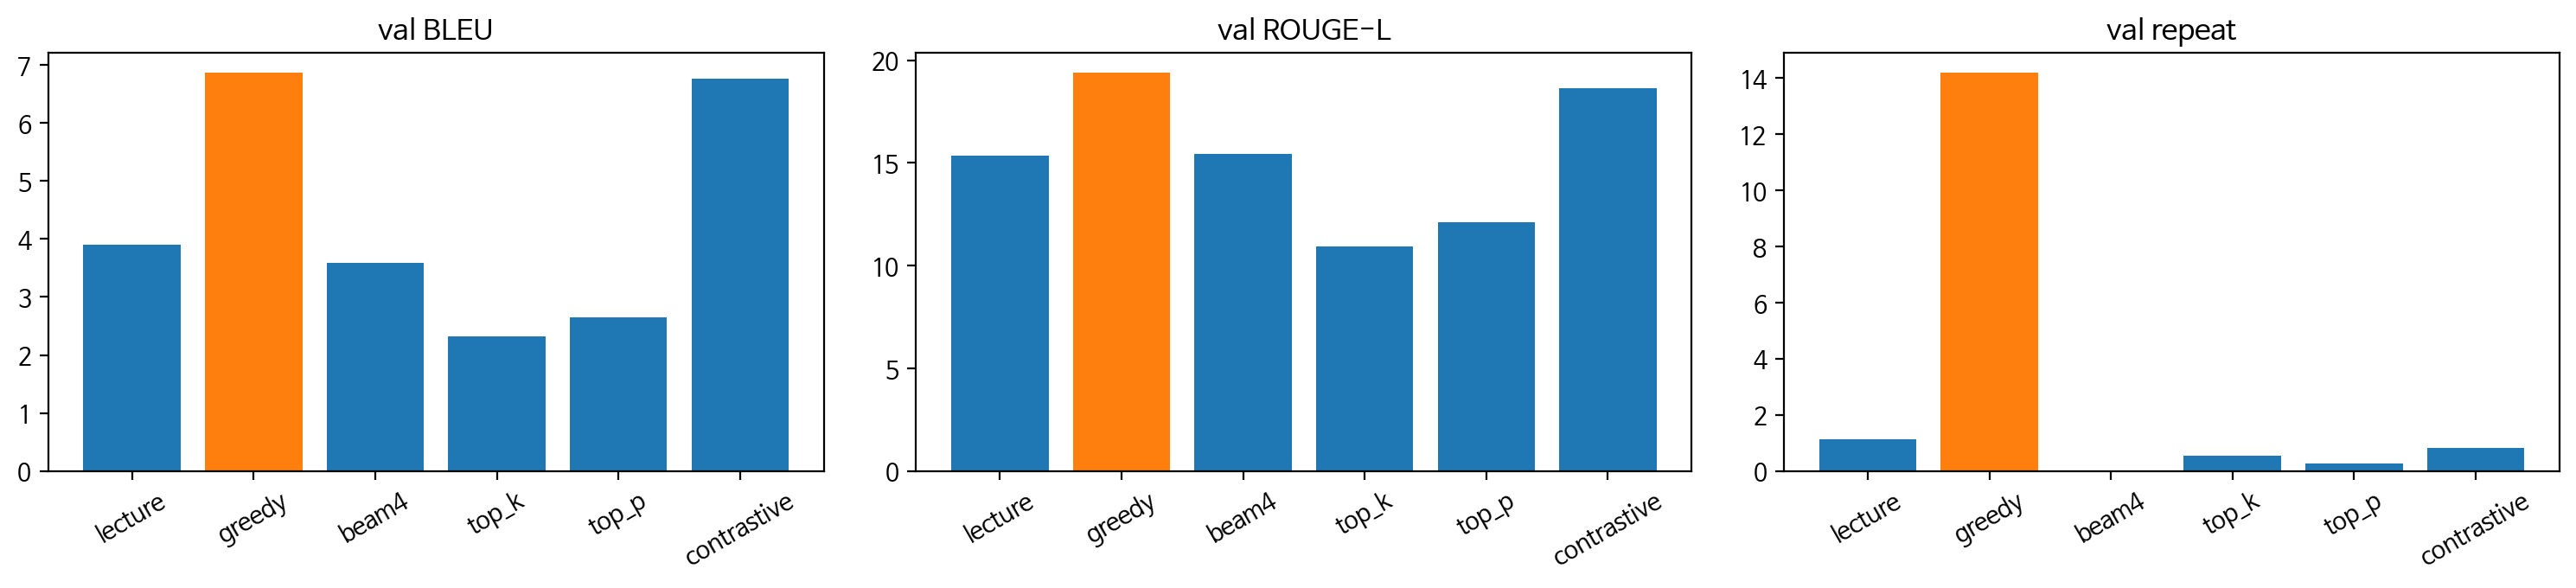

In [75]:
# [추가] 검증셋 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['BLEU', 'ROUGE-L', 'repeat']):
    colors = ['tab:orange' if n == BEST_DECODING else 'tab:blue' for n in search_df.index]
    ax.bar(search_df.index, search_df[col], color=colors)
    ax.set_title(f'val {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [76]:
# [추가] 선택한 디코딩 설정으로 테스트셋 평가
run_eval('sft_v2+best', model, BEST_GEN_ARGS)
compare('sft_v2', 'sft_v2+best')

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,sft_v2,sft_v2+best,변화(b-a)
BLEU,4.55,6.00,1.45
ROUGE-1,18.33,19.75,1.42
ROUGE-2,8.47,10.74,2.26
ROUGE-L,16.23,18.32,2.09
distinct-2,57.31,48.21,-9.10
repeat,1.39,16.28,14.89
avg_len,45.55,40.33,-5.22


In [77]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del model, trainer, train_dataset
clear_memory()

## 10. 개선 ③ : Reward Model 개선 → `rm_v2`

| 변경 | 이유 |
|---|---|
| ranking 을 **[1등 번호, 2등 번호, 3등 번호]** 로 해석 | 3-3 검증: 이 해석에서 ChatGPT 답변이 거의 항상 1등 |
| 답변 텍스트에 `clean_text` 적용 | SFT와 같은 정제 (따옴표·파싱 잔재 제거) |
| 질문에 SFT 템플릿을 씌워 학습 | PPO에서 RM이 받는 입력(템플릿+질문+답변)과 형식을 맞춤 |
| 학습 쌍 1,000 → 3,000 | 강의는 빠른 실습용으로 전체 약 3만 쌍 중 1,000쌍만 사용 |

In [78]:
# [추가] 올바른 해석으로 ranking dataset 생성
total_data_ranking2chosen_v2 = []
for tmp in rm_train_raw:
    order = tmp['ranking']                          # [1등 completion 번호, 2등 번호, 3등 번호]
    for a, b in [(0, 1), (0, 2), (1, 2)]:           # 1등>2등, 1등>3등, 2등>3등
        chosen = clean_text(tmp[f'completion_{order[a]}'])
        rejected = clean_text(tmp[f'completion_{order[b]}'])
        if not chosen or not rejected or chosen == rejected:   # 빈 답변/같은 답변 쌍은 학습 신호가 없으므로 제외
            continue
        total_data_ranking2chosen_v2.append({
            'prompt': build_prompt(tmp['prompt']),   # [변경] SFT 템플릿 형식으로
            'chosen': chosen,
            'rejected': rejected,
        })

random.seed(230319)
random.shuffle(total_data_ranking2chosen_v2)

train_data = total_data_ranking2chosen_v2[:3000]       # [변경] 1000 -> 3000
eval_data = total_data_ranking2chosen_v2[3000:3200]
print(len(total_data_ranking2chosen_v2), len(train_data), len(eval_data))
print(train_data[0])

29242 3000 200
{'prompt': '### Instruction(명령어):\n장래희망이 없어\n\n### Response(응답):', 'chosen': '그러한 생각은 매우 안좋은 상황입니다. 하지만 모든 일에는 해결책이 있다는 것을 기억해주세요. 방법은 먼저 자신의 장점, 관심사, 능력을 파악하고 창의적으로 생각해봅니다. 또한, 새로운 것을 배우거나 경험을 쌓아보는 것도 도움이 될 수 있습니다. 무엇보다도 포기하지 않고 끈기 있게 노력하면 미래에 빛나는 가능성이 충분히 열립니다.', 'rejected': '요\n\n나는 현재 상황에 만족하고 있어서 미래 희망이 없어요. 하지만 나는 늘 배우고 발전하는 것을 좋아하고, 나의 능력을 개발하고 나아가는 것을 좋아해요. 그래서 나는 나의 능력을 발전시키고 나아가는 것을 희망해요.'}


In [79]:
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=1)

trainer.fit(use_lora=0)

model.save_pretrained('models/output_2_RM_v2')
torch.save(model.value_head.state_dict(), 'models/output_2_RM_v2/value_head.pt')

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/750 [00:00<?, ?it/s]

In [80]:
# [추가] RM 정확도 비교 (같은 holdout 쌍)
RM_SCORES['rm_v2'] = rm_pairwise_accuracy(model, rm_eval_pairs, use_template=True)
pd.DataFrame(RM_SCORES).T.round(3)

,accuracy,mean_margin
rm_v1,90.111,0.170
rm_v2,95.111,8.228


In [81]:
# [추가] 강의의 inference_RM 예시 문장으로도 확인 (rm_v2 는 템플릿 형식으로 학습했으므로 질문을 함께 넣음)
q = '인공지능이 뭐야?'
examples = ['인공지능은 똥멍청이 입니다',
            '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.']
for text, s in zip(examples, rm_scores(model, [q] * len(examples), examples, use_template=True)):
    print(f'reward {s:.3f} | {text[:60]}')

reward -4.293 | 인공지능은 똥멍청이 입니다
reward -0.511 | 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을


In [82]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del model, trainer, train_dataset, eval_dataset
clear_memory()

## 11. 개선 ④ : PPO 개선 → `ppo_v2`

| 변경 | 이유 |
|---|---|
| actor / initial model = `sft_v2` | 정제 데이터로 학습한 더 나은 출발점 |
| critic / reward model = `rm_v2` | 라벨을 바로잡은 RM |
| PPO 프롬프트에 SFT 템플릿 적용 | SFT·RM과 같은 입력 형식에서 생성·학습 |
| `padding_side="left"` | 배치 안의 짧은 프롬프트가 패딩 뒤에서 생성을 시작하지 않도록 |
| `max_length` 128 → 160 | 템플릿이 붙어 프롬프트가 길어진 만큼 답변 공간 확보 |
| `num_episodes` 10 → 20 | 학습에 쓰는 프롬프트 240 → 480개 |
| 생성 입력에서 `token_type_ids` 제외 | 학습 단계의 actor forward 에는 없는 입력이라, 생성할 때와 학습할 때 조건을 같게 맞춤 |

In [83]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT_v2', lora_rank=0).to(torch.cuda.current_device())    # [변경]
    critic = GPTCritic(pretrained='models/output_2_RM_v2', lora_rank=0).to(torch.cuda.current_device())   # [변경]
    # GPTCritic 은 백본만 불러오고 value head 는 새로 만든다. RM 학습에서 얻은 head 를 덮어쓴다.
    critic.value_head.load_state_dict(torch.load('models/output_2_RM_v2/value_head.pt'))                  # [변경]
    tokenizer = AutoTokenizer.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="left",    # [변경] right -> left
        model_max_length=512
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

In [84]:
list_prompt = [build_prompt(p) for p in ppo_train_prompts]   # [변경] SFT 템플릿 적용

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items() if k != 'token_type_ids'}   # [변경] token_type_ids 제외 (학습 시 actor forward 에는 없으므로 생성 조건을 맞춤)

print(tokenizer.decode(tokenize_fn(list_prompt[:2])['input_ids'][1]))   # 왼쪽에 패딩(</s>)이 붙는지 확인

</s></s></s></s></s></s></s></s></s></s></s></s></s> ### Instruction(명령어):
개포주공아파트는 몇 단지로 이루어져 있나?

### Response(응답):


In [85]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=160,           # [변경] 128 -> 160
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

trainer.fit(list_prompt,
            num_episodes=20,                  # [변경] 10 -> 20
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO_v2')

Episode [1/20]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/20]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/20]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [19/20]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [20/20]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

In [86]:
# [추가] 같은 디코딩(BASE)과 최적 디코딩(best) 두 가지로 평가
run_eval('ppo_v2', actor.model, BASE_GEN_ARGS)
run_eval('ppo_v2+best', actor.model, BEST_GEN_ARGS)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len,RM(v1)
base,0.08,0.99,0.09,0.89,21.44,6.65,125.79,NaN
sft_v1,5.05,17.90,8.56,15.11,50.45,1.26,50.28,-3.36
ppo_v1,4.65,17.09,7.77,15.18,49.33,1.64,51.62,-3.36
sft_v2,4.55,18.33,8.47,16.23,57.31,1.39,45.55,NaN
sft_v2+best,6.00,19.75,10.74,18.32,48.21,16.28,40.33,NaN
ppo_v2,4.73,19.06,8.79,16.96,54.53,1.09,42.28,NaN
ppo_v2+best,6.28,19.59,10.83,18.43,48.35,15.47,37.67,NaN


In [87]:
# [추가] 다음 단계를 위해 GPU 메모리 정리
del actor, critic, initial_model, reward_model, actor_optim, critic_optim, trainer
clear_memory()

## 12. 종합 평가

모든 모델의 테스트셋 답변을 **같은 심판 RM 두 개(`rm_v1`, `rm_v2`)** 로 채점해 표 하나로 비교합니다.
`reference(ChatGPT)` 는 정답 답변 자체를 채점한 값으로, RM 점수의 **상한선(참고용)** 입니다.

> 주의: `ppo_v1`은 `rm_v1`, `ppo_v2`는 `rm_v2` 점수를 높이도록 학습되었기 때문에 각자의 RM 점수에서는 유리합니다. 그래서 RM 점수만이 아니라 **정답과의 겹침(BLEU·ROUGE)** 과 **반복률**을 함께 봐야 합니다.

In [88]:
# [추가] 저장해둔 RM 불러오기 함수
def load_rm(path):
    with NaiveStrategy().model_init_context():
        rm = GPTRM_custom(pretrained=path, lora_rank=0, tokenizer=rm_tokenizer).to(device)
    rm.value_head.load_state_dict(torch.load(f'{path}/value_head.pt', map_location=device))
    return rm

judge_v1 = load_rm('models/output_2_RM')      # 강의 RM (질문 그대로 형식)
judge_v2 = load_rm('models/output_2_RM_v2')   # 개선 RM (템플릿 형식)

for name in RESULTS:
    SCORES[name]['RM(v1)'] = float(np.mean(rm_scores(judge_v1, test_q, RESULTS[name], use_template=False)))
    SCORES[name]['RM(v2)'] = float(np.mean(rm_scores(judge_v2, test_q, RESULTS[name], use_template=True)))

ref_scores = {'RM(v1)': float(np.mean(rm_scores(judge_v1, test_q, test_ref, use_template=False))),
              'RM(v2)': float(np.mean(rm_scores(judge_v2, test_q, test_ref, use_template=True)))}
ref_scores.update(evaluate_answers(test_ref, test_ref))       # 정답끼리 비교 = 텍스트 지표의 최댓값

ORDER = ['base', 'sft_v1', 'ppo_v1', 'sft_v2', 'sft_v2+best', 'ppo_v2', 'ppo_v2+best']
final_df = pd.DataFrame(SCORES).T.loc[ORDER]
final_df.loc['reference(ChatGPT)'] = pd.Series(ref_scores)
final_df = final_df[['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'distinct-2', 'repeat', 'avg_len', 'RM(v1)', 'RM(v2)']]
final_df.round(2)

,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,distinct-2,repeat,avg_len,RM(v1),RM(v2)
base,0.08,0.99,0.09,0.89,21.44,6.65,125.79,-3.55,-6.96
sft_v1,5.05,17.90,8.56,15.11,50.45,1.26,50.28,-3.36,5.68
ppo_v1,4.65,17.09,7.77,15.18,49.33,1.64,51.62,-3.36,5.57
sft_v2,4.55,18.33,8.47,16.23,57.31,1.39,45.55,-3.41,4.39
sft_v2+best,6.00,19.75,10.74,18.32,48.21,16.28,40.33,-3.43,1.52
ppo_v2,4.73,19.06,8.79,16.96,54.53,1.09,42.28,-3.41,4.50
ppo_v2+best,6.28,19.59,10.83,18.43,48.35,15.47,37.67,-3.44,1.43
reference(ChatGPT),97.32,100.00,100.00,100.00,82.70,1.42,46.50,-3.42,2.10


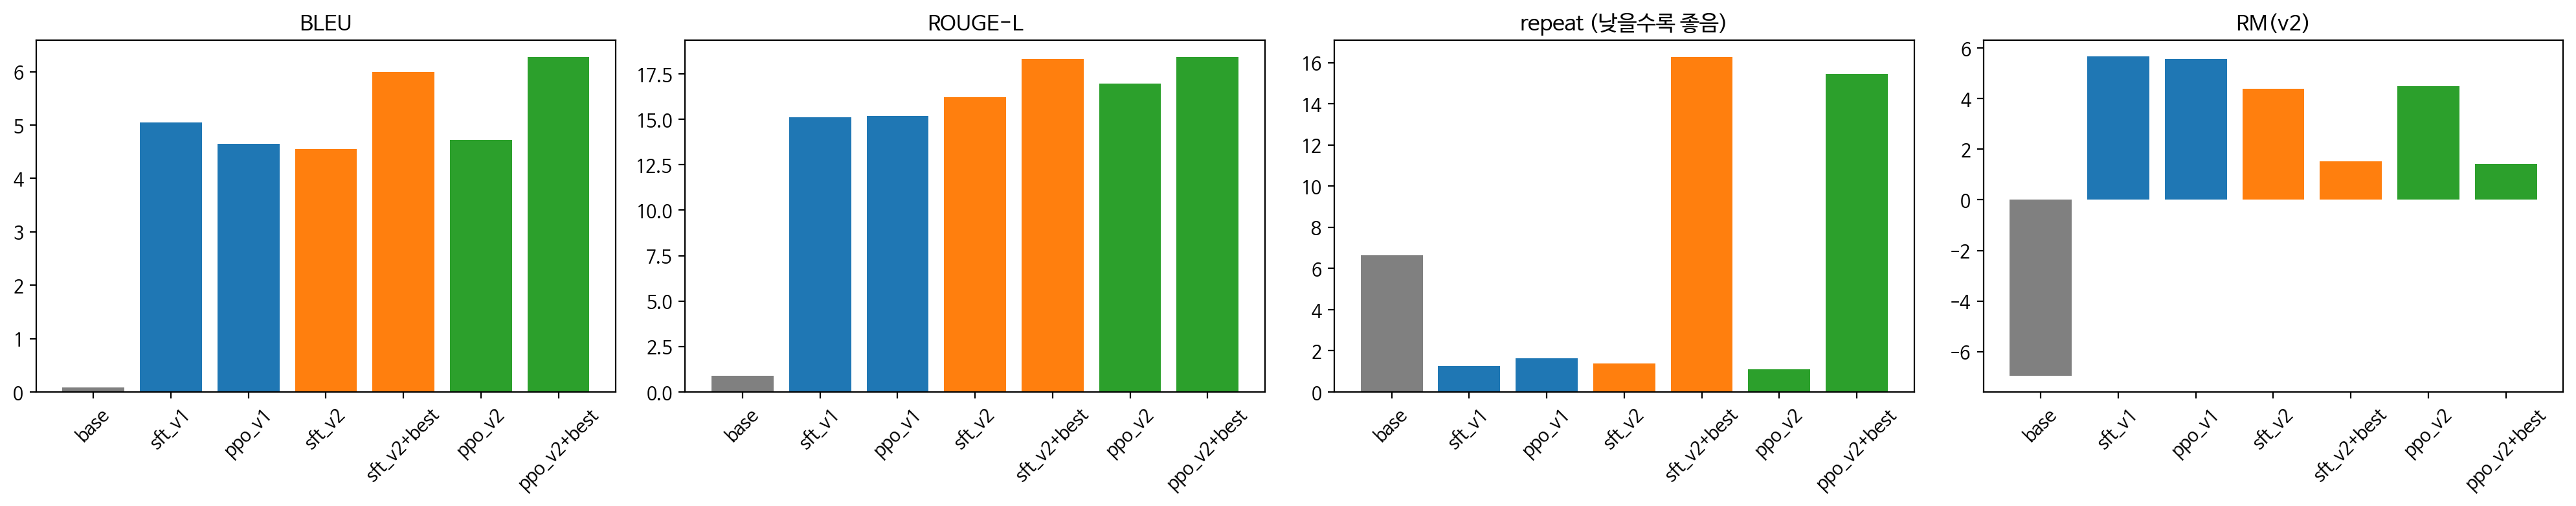

       accuracy  mean_margin
rm_v1    90.111        0.170
rm_v2    95.111        8.228


In [89]:
# [추가] 주요 지표 시각화
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ['BLEU', 'ROUGE-L', 'repeat', 'RM(v2)']):
    vals = final_df.loc[ORDER, col]
    ax.bar(vals.index, vals.values, color=['gray', 'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green'])
    ax.set_title(col + (' (낮을수록 좋음)' if col == 'repeat' else ''))
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(pd.DataFrame(RM_SCORES).T.round(3))   # RM 자체 정확도

In [90]:
# [추가] 정성 비교: 대표 모델 4개의 답변을 나란히
show_samples(['base', 'sft_v1', 'ppo_v1', 'sft_v2+best', 'ppo_v2+best'], idxs=range(6))

[질문] 이별 일년 반
[정답(ChatGPT)] 이별 일년 반이란 말은, 이별한 후 일년 혹은 그 이상 동안 많은 변화가 있을 수 있다는 것을 의미합니다. 이는 마음이 아프고 슬픈 시간 동안에도, 시간이 흐르면서 마음이 치유되고 새로운 시작을 해 나갈 수 있음을 나타냅니다. 따라서 이별 일년 반이라는 말은, 이별을 겪은 사람들에게 더 나은 미래를 기대할 수 있다는 긍정적인 메세지를 전달합니다.
--- [base] ##스타그램 #셀카 #셀피 #selfie #daily #instagood #like4like #ootd #소통 #좋아요
#맞팔 #선팔 #일상 #데일리 #오오티디 #cafe #coffee #f4f #l4l #lfl #followme #outfit #menswear #20190706 #미
--- [sft_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 분들이라면 그 아픔을 느끼실 수 있을 것입니다. 함께 새로운 시작을 해보는 것은 어떨까요?
--- [ppo_v1] '저는 AI 어시스턴트이기 때문에 이별 일년 반에 대한 정보를 알 수 없습니다. 하지만 이별을 경험한 사람들은 서로를 이해하고 존중하며 새로운 인연을 만들어 나가는 것이 중요합니다. 그리고 그 과정에서 서로의 아픔과 상처를 치유하는 것이 중요합니다.\n\n마지막으로, 이별을 경험한 사람들은 서로에게 더 나은 관계를 맺을 수 있는 기회를 제공할 수 있습니다. 함께 시간을 보내는 것도 좋은 방법입니다. 이별은 시간이 지날수록 더욱 깊어지고 상처는 
--- [sft_v2+best] 이별은 언제나 아픈 일이지만, 시간이 지나면서 조금씩 치유될 수 있습니다. 이별은 언제나 아픈 일이지만, 시간이 지나면서 조금씩 치유될 수 있습니다. 이별은 언제나 아픈 일이지만, 시간이 지나면서 조금씩 치유될 것입니다. 그리고 그 시간이 지나면 새로운 시작을 할 수 있습니다.
--- [ppo_v2+best] 이별은 언제나 아픈 일이지만, 시간이 지나면서 조금씩 

In [91]:
# [추가] 강의에서 사용한 4개 질문으로도 최종 모델 확인
final_model = AutoModelForCausalLM.from_pretrained('models/output_3_PPO_v2').to(device)
lecture_q = ['불고기용 고기 한우에요?',
             '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
             '시카고 오헤어 국제공항은 어디에 있어?',
             '오늘 미세먼지 어때?']
for q, a in zip(lecture_q, generate_answers(final_model, lecture_q, BEST_GEN_ARGS)):
    print(f'Q: {q}\nA: {a}\n')

generate:   0%|          | 0/1 [00:00<?, ?it/s]

Q: 불고기용 고기 한우에요?
A: 저는 인공지능 챗봇이므로 불고기용 고기의 종류와 양에 대한 정보를 알 수 없습니다. 하지만 일반적으로 불고기용 고기는 한우, 돼지고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다. 따라서 한우는 한우, 돼지고기, 소고기, 돼지고기 등 다양한 부위를 사용합니다.

Q: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
A: 리처드 닉슨은 46대 부통령직을 수행한 년도는 1947년입니다.

Q: 시카고 오헤어 국제공항은 어디에 있어?
A: 시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.

Q: 오늘 미세먼지 어때?
A: 저는 인공지능 챗봇이기 때문에 미세먼지 여부를 판단할 수 없습니다. 하지만 미세먼지 농도가 높을 때는 실외 활동을 자제하는 것이 좋습니다. 또한 미세먼지 농도가 높은 날에는 실외에서 대기오염 물질을 배출하는 것이 좋습니다.



In [92]:
# [추가] 결과 저장 (GitHub 에 함께 올리거나 회고 작성 시 참고)
final_df.round(3).to_csv('final_scores.csv')
pd.DataFrame({'question': test_q, 'reference': test_ref, **{k: RESULTS[k] for k in ORDER}}).to_csv(
    'test_generations.csv', index=False)
print('saved: final_scores.csv, test_generations.csv')

saved: final_scores.csv, test_generations.csv


### 12-1. 루브릭별 결과 정리 (※ 실행 결과 수치를 보고 확인·수정)

| 루브릭 | 비교 | 확인할 지표 |
|---|---|---|
| 1. 기존 KoGPT2 vs SFT | `base` → `sft_v1` | BLEU·ROUGE 상승, 템플릿/말투 준수 (5-1) |
| 2. SFT vs RM(PPO) | `sft_v1` → `ppo_v1` / `sft_v2` → `ppo_v2` | RM 점수 변화, 텍스트 지표 유지 여부 (7-1, 12) |
| 3. 정량적 성능 향상 | `sft_v1` → `sft_v2` → `sft_v2+best` → `ppo_v2+best` | 데이터 정제·디코딩·학습 전략별 기여 (8, 9, 10, 11) |

- **데이터 정제 효과** (`sft_v1` → `sft_v2`, 디코딩 동일): 따옴표로 시작하거나 영어로 답하는 패턴이 줄었는지, BLEU·ROUGE가 올랐는지.
- **디코딩 효과** (`sft_v2` → `sft_v2+best`, 모델 동일): 같은 모델에서 디코딩만으로 지표가 얼마나 달라지는지.
- **RM 개선 효과** (`rm_v1` → `rm_v2`): holdout 쌍 정확도 상승 여부.
- **PPO 효과** (`sft_v2+best` → `ppo_v2+best`): RM 점수는 오르지만 BLEU·ROUGE가 떨어진다면, 정책이 RM의 허점을 파고드는 **reward hacking** 가능성을 의심해볼 수 있습니다. (RM이 패딩 포함 전체 위치의 평균으로 점수를 매기는 구조라 길이·형식에 민감할 수 있음)

## 회고
---

- **최종 결과 요약**:

- **기존 KoGPT2 vs SFT 모델 비교 소감**:

- **SFT vs RM(PPO) 적용 모델 비교 소감**:

- **가장 효과가 컸던 개선 / 효과가 없었던 개선**:

- **헷갈렸던 / 인상적이었던 부분**:

- **아쉬웠던 점 / 다음에 시도해보고 싶은 것**: